# Entrenamiento del Modelo — Deteccion de Fraude

In [25]:
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

bolivia   = pd.read_parquet('../parquet/train/bolivia_B.parquet')
brasil    = pd.read_parquet('../parquet/train/brasil_B.parquet')
guatemala = pd.read_parquet('../parquet/test/guatemala_B.parquet')

print('Bolivia:',   bolivia.shape,   '| fraudes:', bolivia['is_fraud'].sum())
print('Brasil:',    brasil.shape,    '| fraudes:', brasil['is_fraud'].sum())
print('Guatemala:', guatemala.shape, '| is_fraud nulos:', guatemala['is_fraud'].isna().sum())

Bolivia: (100003, 26) | fraudes: 4919
Brasil: (100000, 26) | fraudes: 3205
Guatemala: (100000, 26) | is_fraud nulos: 100000


In [26]:
TARGET = 'is_fraud'
ID_COLS = ['client_id']

train = pd.concat([bolivia, brasil], ignore_index=True)

feature_cols = [c for c in train.columns if c not in [TARGET] + ID_COLS]

cat_cols = [c for c in feature_cols if train[c].dtype == 'object' or train[c].dtype.name == 'category']
for col in cat_cols:
    train[col]     = train[col].astype('category')
    guatemala[col] = guatemala[col].astype('category')

X = train[feature_cols]
y = train[TARGET].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Feature columns:', len(feature_cols))
print('Categoricas:', cat_cols)
print()
print('X_train:', X_train.shape, '| fraudes:', y_train.sum())
print('X_val:  ', X_val.shape,   '| fraudes:', y_val.sum())

Feature columns: 24
Categoricas: ['card_brand', 'day_of_week']

X_train: (160002, 24) | fraudes: 6499
X_val:   (40001, 24) | fraudes: 1625


## Estrategia de entrenamiento

### Desbalance de clases
El dataset de entrenamiento tiene aproximadamente 4% de fraudes — por cada transaccion
fraudulenta hay ~24 legitimas. Sin correccion, el modelo aprende a ignorar el fraude
porque acertar en legitimas ya le da alta exactitud.

Se combinan dos tecnicas para atacar este problema:

**1. Undersampling moderado (RandomUnderSampler)**
Se reduce la cantidad de transacciones legitimas en el set de entrenamiento hasta
alcanzar una proporcion 10:1 (legitimas:fraudes). No se llega a 1:1 porque tirar
demasiados datos legitimos hace que el modelo pierda patrones reales de comportamiento
normal. El objetivo es balancear sin destruir informacion.

**2. scale_pos_weight**
Adicionalmente se le indica a LightGBM que pese mas los errores cometidos sobre
fraudes durante el entrenamiento. Esto complementa el undersampling sin agregar
complejidad al pipeline.

No se usa SMOTE porque genera ejemplos sinteticos interpolando variables, lo cual
es problematico cuando el dataset tiene variables categoricas como `card_brand`,
`bank_tier` o `day_of_week` — la interpolacion entre categorias no tiene sentido
y puede introducir ruido.

### Threshold de decision
En lugar del 0.5 por defecto, se busca el threshold optimo sobre el set de
validacion que maximice la precision en transacciones presenciales (POS + ATM)
sin sacrificar demasiado recall global.

### Evaluacion
- Precision y recall global.
- Tasa de falsas alertas especificamente en transacciones presenciales (POS + ATM).

In [27]:
fraud_count  = y_train.sum()
legit_count  = len(y_train) - fraud_count
scale_pos_w  = 3

sampling_strategy = fraud_count * 10 / legit_count

rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print('Antes del undersampling:')
print(f'  Legitimas : {legit_count:,}')
print(f'  Fraudes   : {fraud_count:,}')
print(f'  Ratio     : {legit_count/fraud_count:.1f}:1')
print()
print('Despues del undersampling:')
print(f'  Legitimas : {(y_train_res==0).sum():,}')
print(f'  Fraudes   : {(y_train_res==1).sum():,}')
print(f'  Ratio     : {(y_train_res==0).sum()/(y_train_res==1).sum():.1f}:1')
print()

model = lgb.LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    scale_pos_weight=scale_pos_w,
    random_state=42,
    verbose=-1
)

model.fit(
    X_train_res, y_train_res,
    categorical_feature=cat_cols,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(100, verbose=False),
               lgb.log_evaluation(period=100)]
)

print(f'Mejor iteracion        : {model.best_iteration_}')
print(f'Mejor average_precision: {model.best_score_["valid_0"]["average_precision"]:.6f}')

Antes del undersampling:
  Legitimas : 153,503
  Fraudes   : 6,499
  Ratio     : 23.6:1

Despues del undersampling:
  Legitimas : 15,350
  Fraudes   : 6,499
  Ratio     : 2.4:1

[100]	valid_0's average_precision: 0.759966	valid_0's binary_logloss: 0.302801
Mejor iteracion        : 69
Mejor average_precision: 0.761218


In [28]:
y_pred_proba = model.predict_proba(X_val)[:, 1]
y_pred       = (y_pred_proba >= 0.5).astype(int)

print('=== Resultados en validacion (threshold 0.5) ===\n')
print(classification_report(y_val, y_pred, target_names=['Legitima', 'Fraude'], digits=4))

cm = confusion_matrix(y_val, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Negativos : {tn:,}')
print(f'Falsos Positivos     : {fp:,}')
print(f'Falsos Negativos     : {fn:,}')
print(f'Verdaderos Positivos : {tp:,}')
print()

val_data = X_val.copy()
val_data['is_fraud']    = y_val.values
val_data['pred_fraude'] = y_pred
val_data['pred_proba']  = y_pred_proba

presencial_mask = val_data['is_high_risk_channel'] == 0
fp_presencial   = ((val_data['pred_fraude'] == 1) & (val_data['is_fraud'] == 0) & presencial_mask).sum()
total_presencial = presencial_mask.sum()

print(f'Falsos positivos en presencial : {fp_presencial:,} de {total_presencial:,} ({fp_presencial/total_presencial*100:.2f}%)')

=== Resultados en validacion (threshold 0.5) ===

              precision    recall  f1-score   support

    Legitima     0.9894    0.9464    0.9674     38376
      Fraude     0.3750    0.7600    0.5022      1625

    accuracy                         0.9388     40001
   macro avg     0.6822    0.8532    0.7348     40001
weighted avg     0.9644    0.9388    0.9485     40001

Verdaderos Negativos : 36,318
Falsos Positivos     : 2,058
Falsos Negativos     : 390
Verdaderos Positivos : 1,235

Falsos positivos en presencial : 238 de 21,641 (1.10%)


In [29]:
thresholds = np.arange(0.10, 0.90, 0.01)
results = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_val, y_pred_t).ravel()
    fp_pres = ((y_pred_t == 1) & (y_val.values == 0) & presencial_mask.values).sum()
    total_pres = presencial_mask.sum()

    results.append({
        'threshold'        : round(t, 2),
        'precision'        : precision_score(y_val, y_pred_t, zero_division=0),
        'recall'           : recall_score(y_val, y_pred_t),
        'f1'               : f1_score(y_val, y_pred_t, zero_division=0),
        'fp_total'         : fp_t,
        'fn_total'         : fn_t,
        'fp_presencial'    : fp_pres,
        'fp_presencial_pct': fp_pres / total_pres * 100,
    })

results_df = pd.DataFrame(results)

best_f1_row   = results_df.loc[results_df['f1'].idxmax()]
best_pres_row = results_df[results_df['fp_presencial_pct'] <= 0.20].iloc[0]

print('=== Threshold con mejor F1 ===')
print(best_f1_row[['threshold','precision','recall','f1','fp_presencial','fp_presencial_pct']].to_string())
print()
print('=== Threshold con FP presencial <= 0.20% ===')
print(best_pres_row[['threshold','precision','recall','f1','fp_presencial','fp_presencial_pct']].to_string())

THRESHOLD = float(best_pres_row['threshold'])
print(f'\nThreshold seleccionado: {THRESHOLD}')

=== Threshold con mejor F1 ===
threshold            0.860000
precision            0.938345
recall               0.683692
f1                   0.791029
fp_presencial        8.000000
fp_presencial_pct    0.036967

=== Threshold con FP presencial <= 0.20% ===
threshold             0.720000
precision             0.759685
recall                0.712000
f1                    0.735070
fp_presencial        24.000000
fp_presencial_pct     0.110901

Threshold seleccionado: 0.72


In [30]:
THRESHOLD = 0.86

y_pred_final = (y_pred_proba >= THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(y_val, y_pred_final).ravel()

fp_pres      = ((y_pred_final == 1) & (y_val.values == 0) & presencial_mask.values).sum()
total_pres   = presencial_mask.sum()

print('=== Resultados finales en validacion (threshold 0.86) ===\n')
print(classification_report(y_val, y_pred_final, target_names=['Legitima', 'Fraude'], digits=4))
print(f'Verdaderos Negativos : {tn:,}')
print(f'Falsos Positivos     : {fp:,}')
print(f'Falsos Negativos     : {fn:,}')
print(f'Verdaderos Positivos : {tp:,}')
print()
print(f'FP en presencial     : {fp_pres:,} de {total_pres:,} ({fp_pres/total_pres*100:.4f}%)')
print(f'Threshold usado      : {THRESHOLD}')

=== Resultados finales en validacion (threshold 0.86) ===

              precision    recall  f1-score   support

    Legitima     0.9868    0.9981    0.9924     38376
      Fraude     0.9383    0.6837    0.7910      1625

    accuracy                         0.9853     40001
   macro avg     0.9626    0.8409    0.8917     40001
weighted avg     0.9848    0.9853    0.9842     40001

Verdaderos Negativos : 38,303
Falsos Positivos     : 73
Falsos Negativos     : 514
Verdaderos Positivos : 1,111

FP en presencial     : 8 de 21,641 (0.0370%)
Threshold usado      : 0.86


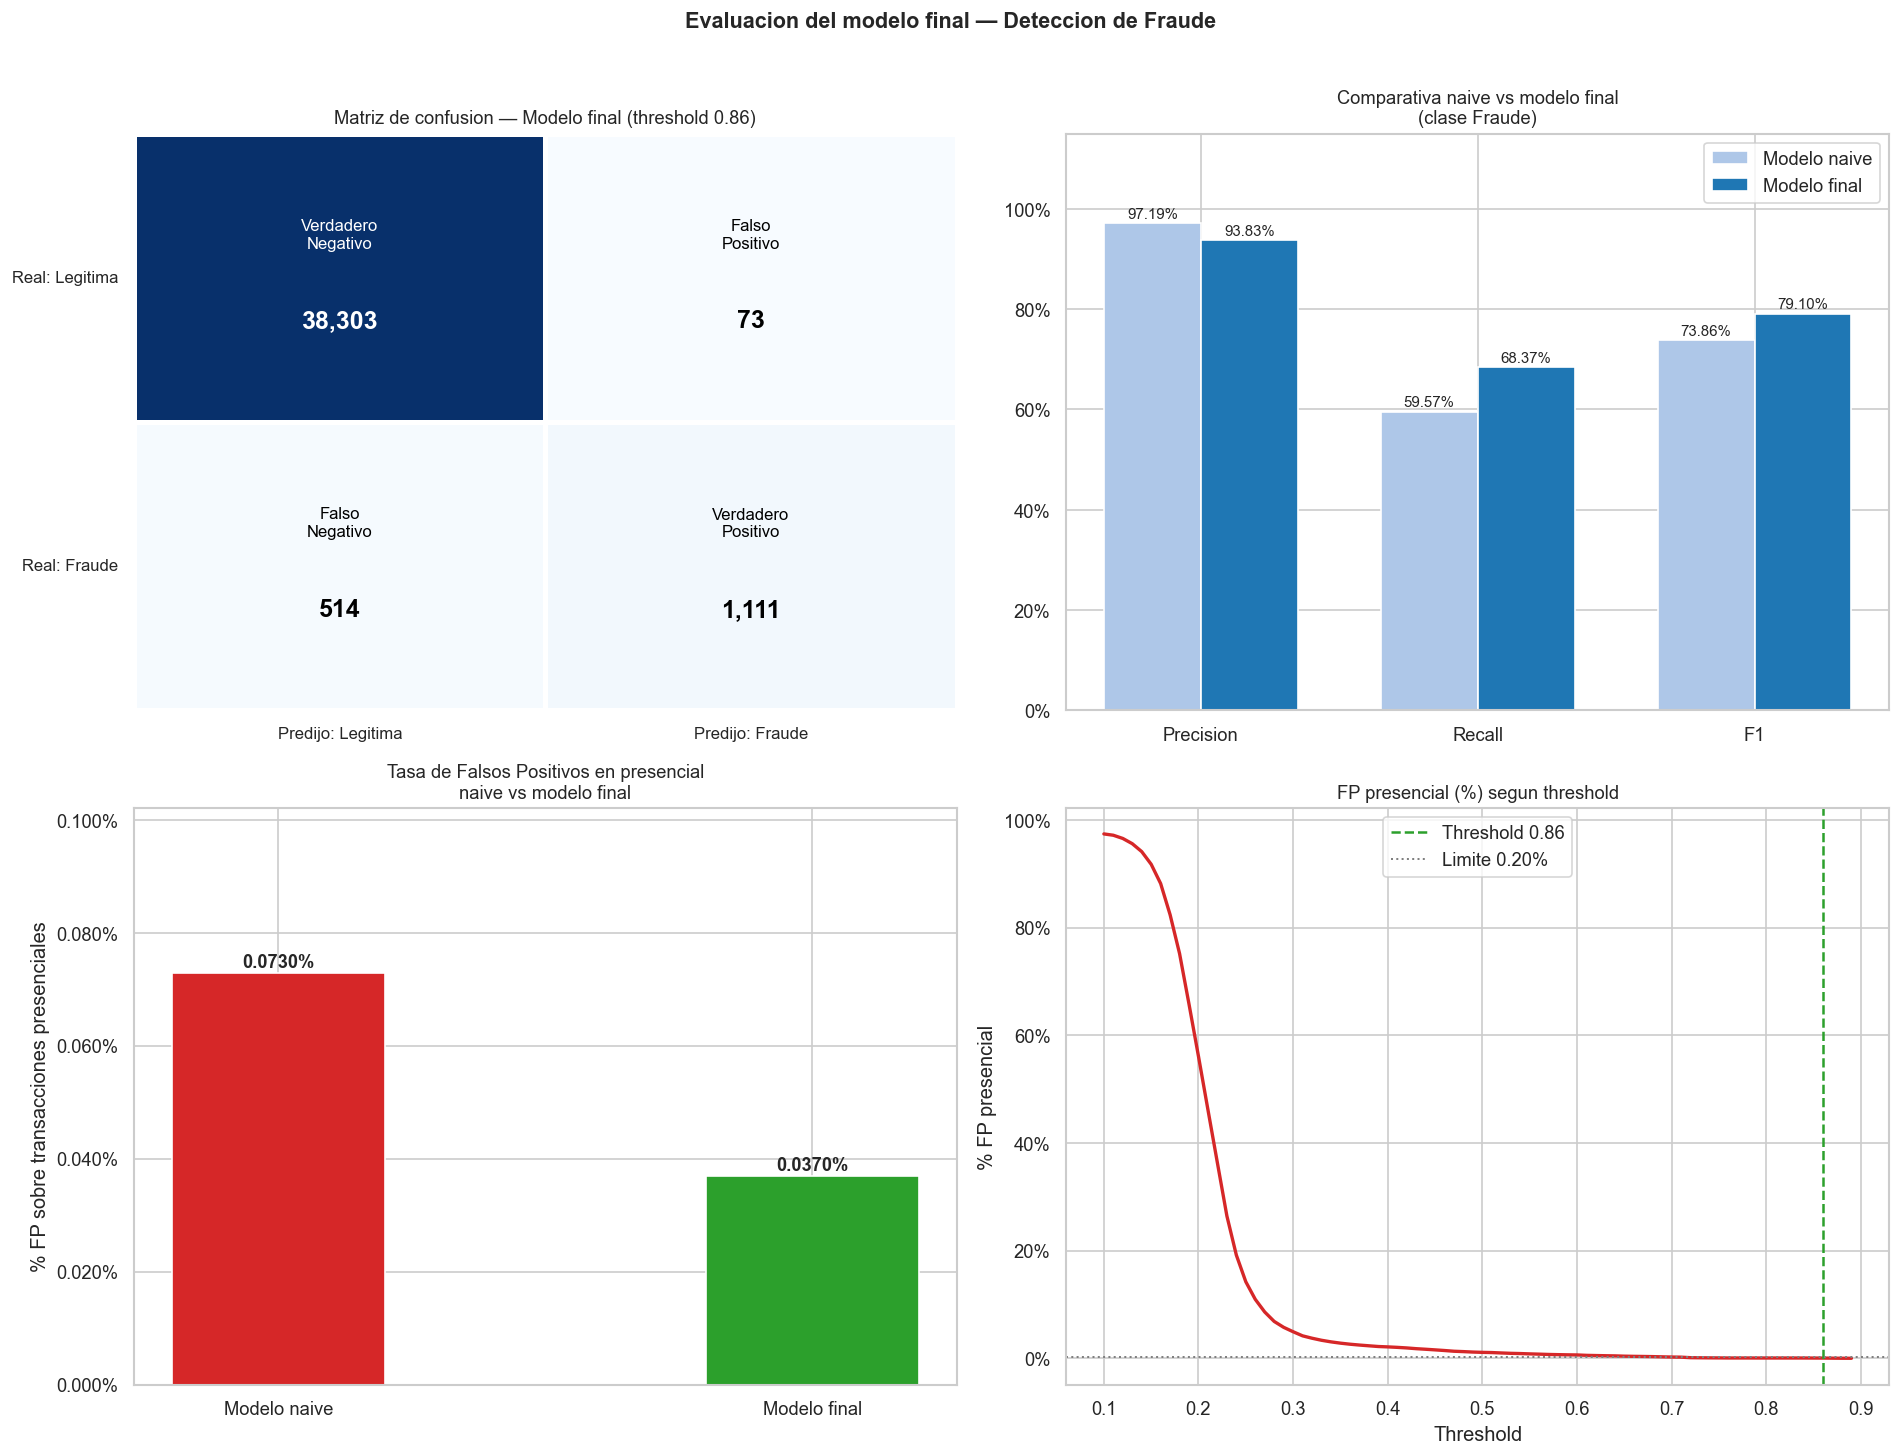

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Matriz de confusion ---
cm = confusion_matrix(y_val, y_pred_final)
labels = [['Verdadero\nNegativo', 'Falso\nPositivo'],
          ['Falso\nNegativo',     'Verdadero\nPositivo']]

sns.heatmap(cm, annot=False, cmap='Blues', linewidths=2,
            linecolor='white', ax=axes[0][0], cbar=False)
for i in range(2):
    for j in range(2):
        axes[0][0].text(j + 0.5, i + 0.35, labels[i][j],
                ha='center', va='center', fontsize=10,
                color='white' if cm[i,j] > cm.max()*0.5 else 'black')
        axes[0][0].text(j + 0.5, i + 0.65, f'{cm[i,j]:,}',
                ha='center', va='center', fontsize=15, fontweight='bold',
                color='white' if cm[i,j] > cm.max()*0.5 else 'black')
axes[0][0].set_xticklabels(['Predijo: Legitima', 'Predijo: Fraude'], fontsize=10)
axes[0][0].set_yticklabels(['Real: Legitima', 'Real: Fraude'], fontsize=10, rotation=0)
axes[0][0].set_title('Matriz de confusion — Modelo final (threshold 0.86)', fontsize=11)

# --- Comparativa naive vs modelo final ---
metricas   = ['Precision', 'Recall', 'F1']
naive_vals = [0.9719, 0.5957, 0.7386]
final_vals = [0.9383, 0.6837, 0.7910]

x = np.arange(len(metricas))
w = 0.35
bars1 = axes[0][1].bar(x - w/2, naive_vals, w, label='Modelo naive', color='#aec7e8')
bars2 = axes[0][1].bar(x + w/2, final_vals, w, label='Modelo final', color='#1f77b4')
axes[0][1].set_xticks(x)
axes[0][1].set_xticklabels(metricas, fontsize=11)
axes[0][1].set_ylim(0, 1.15)
axes[0][1].set_title('Comparativa naive vs modelo final\n(clase Fraude)', fontsize=11)
axes[0][1].legend()
axes[0][1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
for bar in list(bars1) + list(bars2):
    axes[0][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{bar.get_height():.2%}', ha='center', fontsize=9)

# --- FP presencial naive vs modelo final ---
categorias = ['Modelo naive', 'Modelo final']
fp_vals    = [28/38376*100, 8/21641*100]
colores    = ['#d62728', '#2ca02c']
bars3 = axes[1][0].bar(categorias, fp_vals, color=colores, width=0.4)
axes[1][0].set_title('Tasa de Falsos Positivos en presencial\nnaive vs modelo final', fontsize=11)
axes[1][0].set_ylabel('% FP sobre transacciones presenciales')
axes[1][0].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars3, fp_vals):
    axes[1][0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                   f'{val:.4f}%', ha='center', fontsize=11, fontweight='bold')
axes[1][0].set_ylim(0, max(fp_vals) * 1.4)

# --- Curva threshold vs FP presencial ---
axes[1][1].plot(results_df['threshold'], results_df['fp_presencial_pct'],
                color='#d62728', linewidth=2)
axes[1][1].axvline(x=0.86, color='#2ca02c', linestyle='--', linewidth=1.5, label='Threshold 0.86')
axes[1][1].axhline(y=0.20, color='gray', linestyle=':', linewidth=1.2, label='Limite 0.20%')
axes[1][1].set_title('FP presencial (%) segun threshold', fontsize=11)
axes[1][1].set_xlabel('Threshold')
axes[1][1].set_ylabel('% FP presencial')
axes[1][1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1][1].legend()

plt.suptitle('Evaluacion del modelo final — Deteccion de Fraude', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [32]:
for col in cat_cols:
    train_categories = X_train_res[col].cat.categories.tolist()
    guatemala[col] = pd.Categorical(guatemala[col], categories=train_categories)

X_gt = guatemala[feature_cols].copy()

gt_pred_proba = model.predict_proba(X_gt)[:, 1]
gt_pred       = (gt_pred_proba >= THRESHOLD).astype(int)

guatemala['pred_proba_fraude'] = gt_pred_proba
guatemala['is_fraud_pred']     = gt_pred.astype(bool)

total_alertas = gt_pred.sum()
pct_alertas   = total_alertas / len(guatemala) * 100

presencial_mask_gt = guatemala['is_high_risk_channel'] == 0
alertas_pres       = guatemala.loc[presencial_mask_gt, 'is_fraud_pred'].sum()
total_pres         = presencial_mask_gt.sum()

ecom_mask_gt = guatemala['is_high_risk_channel'] == 1
alertas_ecom = guatemala.loc[ecom_mask_gt, 'is_fraud_pred'].sum()
total_ecom   = ecom_mask_gt.sum()

print('=== Prediccion en Guatemala ===\n')
print(f'Total transacciones          : {len(guatemala):,}')
print(f'Total alertas de fraude      : {total_alertas:,} ({pct_alertas:.2f}%)')
print()
print(f'Transacciones presenciales   : {total_pres:,}')
print(f'Alertas en presencial        : {alertas_pres:,} ({alertas_pres/total_pres*100:.2f}%)')
print()
print(f'Transacciones ECOM/MOTO      : {total_ecom:,}')
print(f'Alertas en ECOM/MOTO         : {alertas_ecom:,} ({alertas_ecom/total_ecom*100:.2f}%)')

=== Prediccion en Guatemala ===

Total transacciones          : 100,000
Total alertas de fraude      : 2,324 (2.32%)

Transacciones presenciales   : 83,726
Alertas en presencial        : 1,607 (1.92%)

Transacciones ECOM/MOTO      : 16,274
Alertas en ECOM/MOTO         : 717 (4.41%)


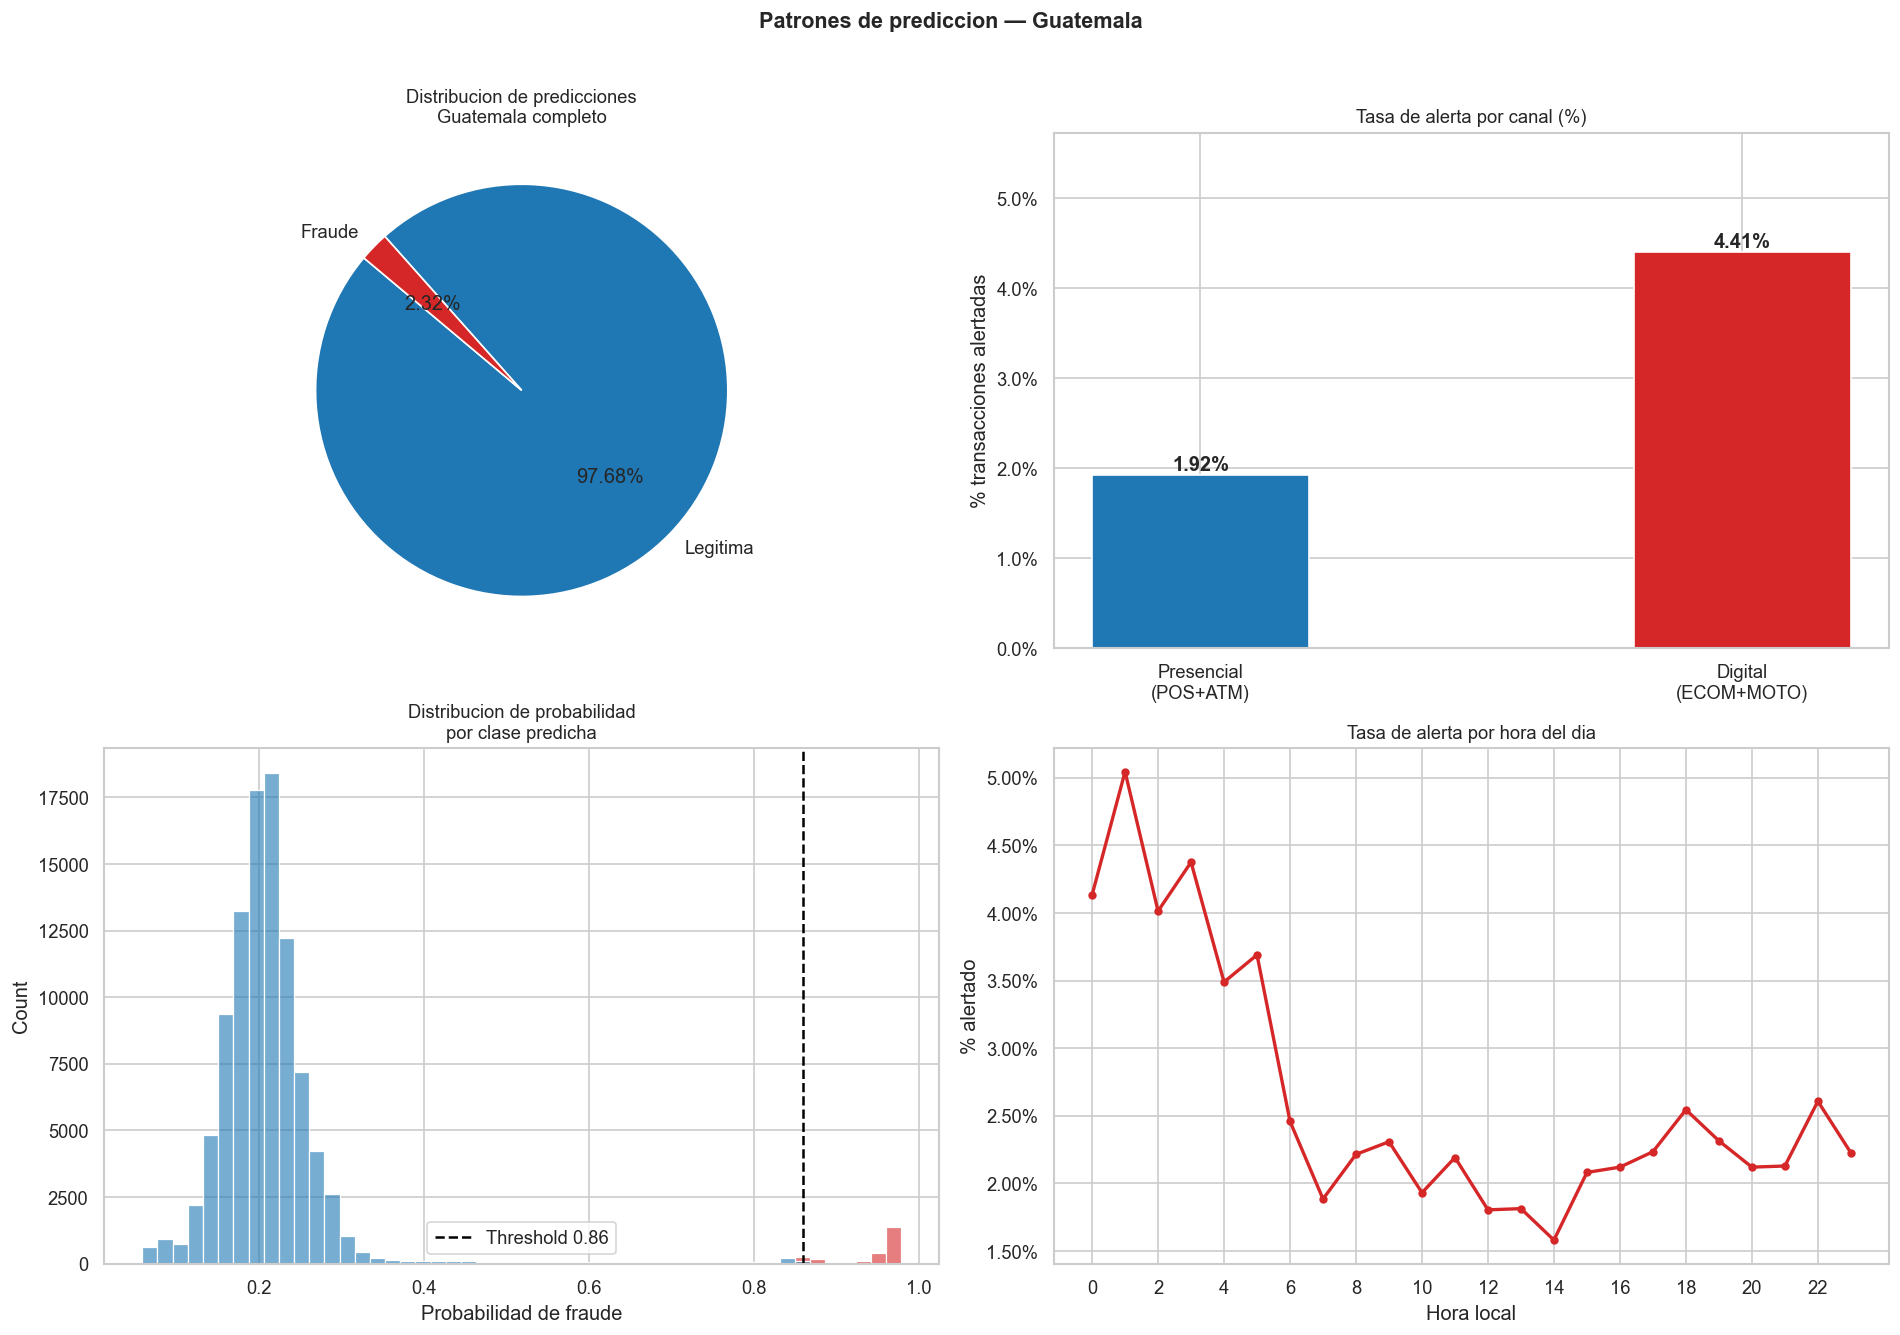

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# --- 1. Distribucion general ---
counts     = guatemala['is_fraud_pred'].value_counts()
labels_pie = ['Legitima', 'Fraude']
colors_pie = ['#1f77b4', '#d62728']
axes[0][0].pie(counts.values, labels=labels_pie, autopct='%1.2f%%',
               colors=colors_pie, startangle=140)
axes[0][0].set_title('Distribucion de predicciones\nGuatemala completo', fontsize=11)

# --- 2. Alertas por canal ---
canales   = ['Presencial\n(POS+ATM)', 'Digital\n(ECOM+MOTO)']
pct_canal = [alertas_pres/total_pres*100, alertas_ecom/total_ecom*100]
bars = axes[0][1].bar(canales, pct_canal, color=['#1f77b4', '#d62728'], width=0.4)
axes[0][1].set_title('Tasa de alerta por canal (%)', fontsize=11)
axes[0][1].set_ylabel('% transacciones alertadas')
axes[0][1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, pct_canal):
    axes[0][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                   f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[0][1].set_ylim(0, max(pct_canal) * 1.3)

# --- 3. Distribucion de probabilidad ---
sns.histplot(data=guatemala, x='pred_proba_fraude', hue='is_fraud_pred',
             bins=50, stat='count', common_norm=False,
             palette={False: '#1f77b4', True: '#d62728'},
             alpha=0.6, ax=axes[1][0])
axes[1][0].axvline(x=THRESHOLD, color='black', linestyle='--',
                   linewidth=1.5, label=f'Threshold {THRESHOLD}')
axes[1][0].set_title('Distribucion de probabilidad\npor clase predicha', fontsize=11)
axes[1][0].set_xlabel('Probabilidad de fraude')
axes[1][0].legend()

# --- 4. Alertas por hora del dia ---
hour_table = guatemala.groupby('hour_local')['is_fraud_pred'].agg(
    total='count', alertas='sum').reset_index()
hour_table['pct'] = hour_table['alertas'] / hour_table['total'] * 100
axes[1][1].plot(hour_table['hour_local'], hour_table['pct'],
                color='#d62728', linewidth=2, marker='o', markersize=4)
axes[1][1].set_title('Tasa de alerta por hora del dia', fontsize=11)
axes[1][1].set_xlabel('Hora local')
axes[1][1].set_ylabel('% alertado')
axes[1][1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1][1].set_xticks(range(0, 24, 2))

plt.suptitle('Patrones de prediccion — Guatemala', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [34]:
sample_30 = guatemala[['is_fraud_pred', 'pred_proba_fraude']].sample(frac=0.30, random_state=42)

print('=== Muestra 30% de predicciones Guatemala ===\n')
print(f'Total filas            : {len(sample_30):,}')
print(f'Fraudes predichos      : {sample_30["is_fraud_pred"].sum():,} ({sample_30["is_fraud_pred"].mean()*100:.2f}%)')
print(f'Legitimas predichas    : {(~sample_30["is_fraud_pred"]).sum():,} ({(~sample_30["is_fraud_pred"]).mean()*100:.2f}%)')
print()
print('Primeras 10 filas:')
print(sample_30.head(10).to_string())
print()
print('Distribucion de probabilidad:')
print(sample_30['pred_proba_fraude'].describe().round(4).to_string())

=== Muestra 30% de predicciones Guatemala ===

Total filas            : 30,000
Fraudes predichos      : 693 (2.31%)
Legitimas predichas    : 29,307 (97.69%)

Primeras 10 filas:
       is_fraud_pred  pred_proba_fraude
75721          False           0.228481
80184          False           0.142294
19864          False           0.243806
76699          False           0.197652
92991          False           0.185344
76434          False           0.131581
84004          False           0.240331
80917          False           0.235562
60767          False           0.219155
50074          False           0.159666

Distribucion de probabilidad:
count    30000.0000
mean         0.2268
std          0.1303
min          0.0589
25%          0.1781
50%          0.2060
75%          0.2335
max          0.9785


In [35]:
import os

os.makedirs('../outputs/', exist_ok=True)

sample_30.to_csv('../outputs/guatemala_predicciones_30pct.csv', index=True)

print(f'Archivo exportado: ../outputs/guatemala_predicciones_30pct.csv')
print(f'Filas            : {len(sample_30):,}')

Archivo exportado: ../outputs/guatemala_predicciones_30pct.csv
Filas            : 30,000
